# Minería de Datos Aplicada al Sector Automotriz Ecuatoriano
## Caso de Estudio: Registro de Vehículos Nuevos — SRI 2026

**Asignatura:** Minería de Datos — UEA-L-UFPTI-009  
**Unidad N°4:** Aplicaciones de Data Mining  
**Tema:** Aplicación práctica de algoritmos predictivos (Decision Tree, Random Forest, KNN) sobre un caso empresarial real.

**Dataset:** `SRI_Vehiculos_Nuevos_2026.csv` — Portal de Datos Abiertos del Servicio de Rentas Internas (Ecuador).  
**Registros:** 241,363 | **Variables:** 20

---

**Problema:** Las empresas automotrices ecuatorianas no cuentan con análisis cuantitativo para identificar qué marcas, modelos y características tienen mayor demanda real, generando sobrestock y pérdida de liquidez.

In [ ]:
# ============================================================
# 1. IMPORTACIÓN DE LIBRERÍAS
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

sns.set_theme(style="darkgrid")
plt.rcParams['figure.dpi'] = 110

print("✅ Librerías cargadas correctamente")

✅ Librerías cargadas correctamente


## 2. Carga del Dataset

Se carga el dataset `SRI_Vehiculos_Nuevos_2026.csv` desde el archivo local.

En Colab, si el archivo aún no está en el entorno, ejecuta la celda de subida.

> **Fuente:** https://www.sri.gob.ec/de-datos-abiertos  
> El dataset contiene 241,363 registros de vehículos nuevos matriculados en Ecuador.

In [ ]:
# ============================================================
# 2. CARGA DEL DATASET SRI
# ============================================================

# En Google Colab puedes subir el archivo ejecutando:
from google.colab import files

uploaded = files.upload()

# Leer el archivo CSV
df = pd.read_csv(
    'SRI_Vehiculos_Nuevos_2026.csv',
    encoding='latin-1',
    sep=None,
    engine='python'
)

# El campo AVALUO viene como texto con coma decimal
# Se convierte a float
df['AVALUO'] = (
    df['AVALUO']
    .astype(str)
    .str.replace(',', '.', regex=False)
    .astype(float)
)

print(f"Total de registros cargados: {len(df):,}")
print(f"Total de variables: {df.shape[1]}")

df.head()

Saving SRI_Vehiculos_Nuevos_2026.csv to SRI_Vehiculos_Nuevos_2026 (1).csv
Total de registros cargados: 241,363
Total de variables: 20


,CATEGORÍA,CÓDIGO DE VEHÍCULO,TIPO TRANSACCIÓN,MARCA,MODELO,PAIS,AÑO MODELO,CLASE,SUB CLASE,TIPO,AVALUO,FECHA PROCESO (DD/MM/AAAA),TIPO SERVICIO,CILINDRAJE,TIPO COMBUSTIBLE,FECHA COMPRA (DD/MM/AAAA),CANTÓN,COLOR 1,COLOR 2,Tipo Identificac Potenc Prop
0,1067774,10740455,COMPRA LOCAL,HINO,FM8JL7D-XG3 AC 7.7 2P 6X4 TM DIESEL,COLOMBIA,2027,VOLQUETA,VOLQUETA,PESADO,156490.0,30/4/2026,PAR,7684,DIESEL,29/4/2026,11315,AMA,NaN,JURIDICA
1,1067772,10611512,COMPRA LOCAL,SHACMAN,X5000 SX12555Y464C AC 12.5 2P 6X4 TA DIESEL,CHINA POPULAR,2027,ESPECIAL,OTROS,PESADO,95390.0,23/4/2026,PAR,12453,DIESEL,31/3/2026,20501,AMA,NaN,NATURAL
2,1067766,10690140,COMPRA LOCAL,JAC,HFC1120KNR AC 4.5 2P 4X2 TM DIESEL,CHINA POPULAR,2027,CAMION,PLATAFORMA-C,PESADO,50457.5,6/5/2026,PAR,4460,DIESEL,27/3/2026,10901,BLA,NaN,JURIDICA
3,1067766,10690145,COMPRA LOCAL,JAC,HFC1120KNR AC 4.5 2P 4X2 TM DIESEL,CHINA POPULAR,2027,CAMION,PLATAFORMA-C,PESADO,50457.5,6/5/2026,PAR,4460,DIESEL,27/3/2026,10901,BLA,NaN,JURIDICA
4,1067766,10690146,COMPRA LOCAL,JAC,HFC1120KNR AC 4.5 2P 4X2 TM DIESEL,CHINA POPULAR,2027,CAMION,PLATAFORMA-C,PESADO,50457.5,6/5/2026,PAR,4460,DIESEL,27/3/2026,10901,BLA,NaN,JURIDICA


 3. Primera Radiografía de los Datos — df.info()
Con info() obtenemos la estructura del DataFrame: número de filas, columnas, tipos de dato y consumo de memoria. Esto nos da una visión inicial de qué variables son numéricas, cuáles son categóricas y cuántos valores no nulos tiene cada una.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 241363 entries, 0 to 241362
Data columns (total 20 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   CATEGORÍA                     241363 non-null  int64  
 1   CÓDIGO DE VEHÍCULO            241363 non-null  int64  
 2   TIPO TRANSACCIÓN              241363 non-null  object 
 3   MARCA                         241363 non-null  object 
 4   MODELO                        241363 non-null  object 
 5   PAIS                          241363 non-null  object 
 6   AÑO MODELO                    241363 non-null  int64  
 7   CLASE                         241363 non-null  object 
 8   SUB CLASE                     241363 non-null  object 
 9   TIPO                          241363 non-null  object 
 10  AVALUO                        241363 non-null  float64
 11  FECHA PROCESO (DD/MM/AAAA)    241363 non-null  object 
 12  TIPO SERVICIO                 241363 non-nul

## 4. Estadísticas Descriptivas — `df.describe()`

De cada variable numérica me imagino una recta entre el **mínimo** y el **máximo**, y ubico la **media** (mean) y los **cuartiles** (25%, 50%, 75%).

El `describe()` permite detectar asimetrías: por ejemplo, si la media es muy distinta de la mediana (50%), existe sesgo en la distribución.

### Fórmulas clave

**Media aritmética:**

$$
\bar{x} = \frac{1}{n} \sum_{i=1}^{n} x_i
$$

**Desviación estándar muestral:**

$$
s = \sqrt{\frac{1}{n-1} \sum_{i=1}^{n} (x_i - \bar{x})^2}
$$

In [ ]:
df.describe()

,CATEGORÍA,CÓDIGO DE VEHÍCULO,AÑO MODELO,AVALUO,CILINDRAJE,CANTÓN
count,2.413630e+05,2.413630e+05,241363.000000,241363.000000,241363.000000,241363.000000
mean,1.013473e+06,1.046983e+07,2026.170242,12287.878429,886.163327,16482.618040
std,5.725646e+04,2.719010e+05,0.680557,19036.801467,1470.229794,6024.771697
min,2.232300e+04,1.937856e+06,1994.000000,80.000000,0.000000,10701.000000
25%,9.983150e+05,1.039113e+07,2026.000000,1280.000000,150.000000,10901.000000
50%,1.019148e+06,1.052148e+07,2026.000000,2100.000000,200.000000,11321.000000
75%,1.044971e+06,1.062874e+07,2027.000000,19999.000000,1497.000000,21701.000000
max,1.067774e+06,1.081305e+07,2027.000000,838800.000000,16956.000000,42003.000000


## 5. Detección de Valores Nulos — `df.isnull().sum()`

`isnull().sum()` indica la sumatoria de datos nulos por variable.

El porcentaje de nulos se calcula como:

$$
\% \text{Nulos} =
\left(
\frac{\sum \text{Valores Faltantes}}{n}
\right)
\times 100
$$

In [ ]:
# Cantidad y porcentaje de nulos por variable

nulos = df.isnull().sum()

porc_nulos = (
    nulos / len(df) * 100
).round(2)

df_nulos = pd.DataFrame({
    'Nulos': nulos,
    '% Nulos': porc_nulos
})

df_nulos[df_nulos['Nulos'] > 0]

,Nulos,% Nulos
COLOR 1,2,0.00
COLOR 2,76165,31.56


## 6. Registros Duplicados

La función `duplicated().sum()` cuenta las filas exactamente idénticas en todas sus columnas.

Los duplicados deben eliminarse para evitar sesgos en el entrenamiento del modelo.

In [ ]:
duplicados = df.duplicated().sum()

porc_dup = (
    duplicados / len(df) * 100
).round(2)

print(
    f"Cantidad de duplicados: "
    f"{duplicados} registros ({porc_dup}%)"
)

Cantidad de duplicados: 27987 registros (11.6%)


## 7. Análisis Exploratorio de Datos (EDA) — 3 Visualizaciones

Generamos tres gráficos para entender el comportamiento del mercado automotriz ecuatoriano:

1. **Top 10 Marcas más demandadas** — barras horizontales.
2. **Distribución del AVALUO** — boxplot con escala logarítmica.
3. **Histograma del Año del Modelo** — distribución temporal.

### Detección de Outliers — Rango Intercuartílico (IQR)

$$
\text{IQR} = Q_3 - Q_1
$$

**Límite superior:**

$$
Q_3 + 1.5 \times \text{IQR}
$$

**Límite inferior:**

$$
Q_1 - 1.5 \times \text{IQR}
$$

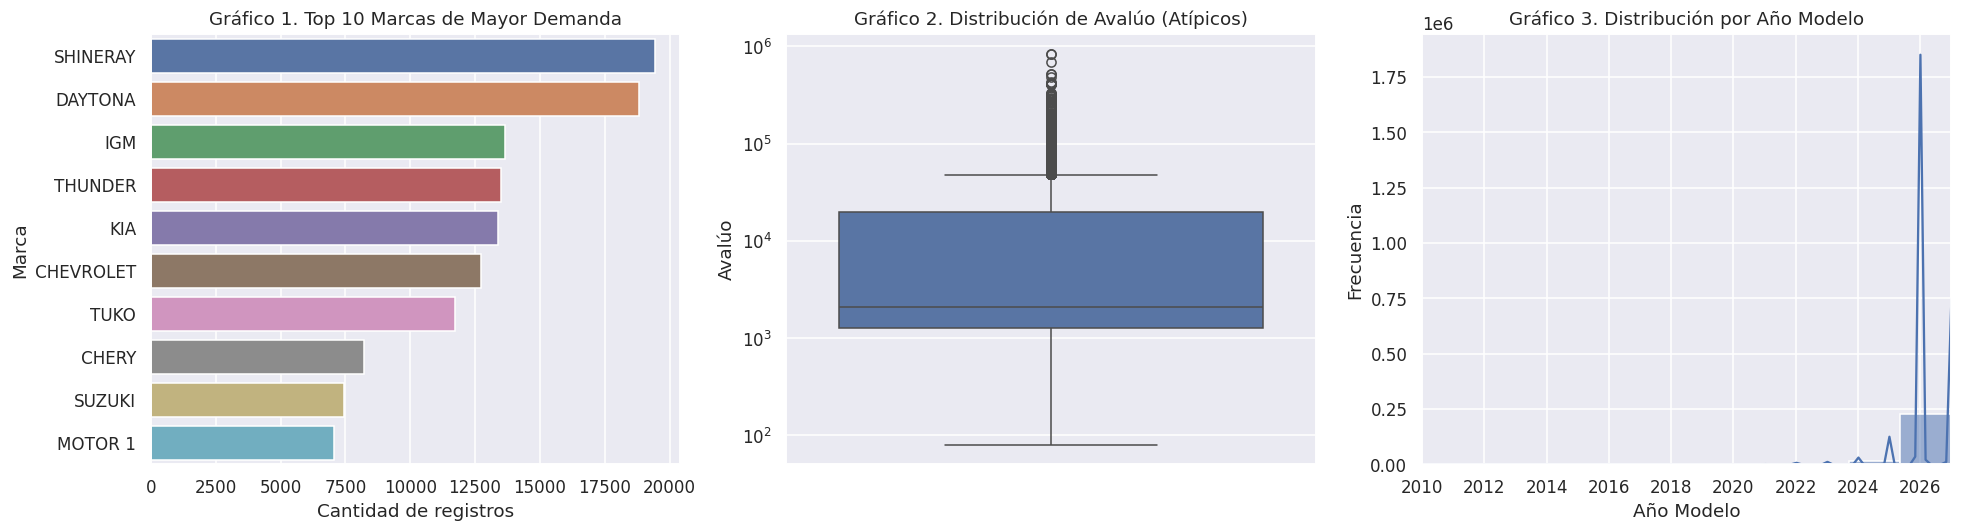

In [ ]:
plt.figure(figsize=(18, 5))

# ============================================================
# GRÁFICO 1: TOP 10 MARCAS
# ============================================================

plt.subplot(1, 3, 1)

top_marcas = df['MARCA'].value_counts().head(10)

sns.barplot(
    x=top_marcas.values,
    y=top_marcas.index,
    hue=top_marcas.index,
    legend=False
)

plt.title('Gráfico 1. Top 10 Marcas de Mayor Demanda')
plt.xlabel('Cantidad de registros')
plt.ylabel('Marca')


# ============================================================
# GRÁFICO 2: BOXPLOT DE AVALUO
# ============================================================

plt.subplot(1, 3, 2)

sns.boxplot(
    y=df['AVALUO']
)

plt.yscale('log')

plt.title('Gráfico 2. Distribución de Avalúo (Atípicos)')
plt.ylabel('Avalúo')


# ============================================================
# GRÁFICO 3: HISTOGRAMA AÑO MODELO
# ============================================================

plt.subplot(1, 3, 3)

sns.histplot(
    df['AÑO MODELO'],
    bins=20,
    kde=True
)

plt.title('Gráfico 3. Distribución por Año Modelo')
plt.xlabel('Año Modelo')
plt.ylabel('Frecuencia')

plt.xlim(
    2010,
    df['AÑO MODELO'].max()
)

plt.tight_layout()
plt.show()

### Análisis de las gráficas

* **Gráfico 1:** Las dos marcas más demandadas (`Shineray` y `Daytona`) pertenecen al segmento de motocicletas, lo que evidencia la vocación del mercado ecuatoriano hacia la movilidad económica.

* **Gráfico 2:** El boxplot muestra una gran cantidad de atípicos por encima del bigote superior: vehículos de alta gama que se desvían fuertemente del avalúo mediano (~$2,100).

* **Gráfico 3:** La distribución del año modelo concentra la mayor densidad entre 2020 y 2026, confirmando que la mayoría del parque registrado corresponde a vehículos recientes.

## 8. Preprocesamiento, Limpieza e Ingeniería de Características

Se aplican tres acciones:

### 1. Limpieza

Eliminación de duplicados e imputación de valores nulos en `COLOR 1` y `COLOR 2`.

### 2. Feature Engineering — Antigüedad del vehículo

$$
\text{Antigüedad}_i =
\text{Año Base} (2026) -
\text{Año del Modelo}_i
$$

### 3. Feature Engineering — Discretización de Avalúo

Se divide el avalúo en 3 categorías ordinales:

- **Bajo**
- **Medio**
- **Alto**

Se utilizan los percentiles 33 y 66:

$$
\text{Categoría}_i =
\begin{cases}
\text{"Bajo"} & \text{si } A_i \leq Q_{33}\\
\text{"Medio"} & \text{si } Q_{33}<A_i\leq Q_{66}\\
\text{"Alto"} & \text{si } A_i>Q_{66}
\end{cases}
$$

In [ ]:
# ============================================================
# 3. LIMPIEZA + FEATURE ENGINEERING
# ============================================================

df_clean = df.drop_duplicates().copy()

# Eliminar registros sin avalúo
df_clean = df_clean.dropna(
    subset=['AVALUO']
)

# Imputación de valores nulos
df_clean['COLOR 1'] = (
    df_clean['COLOR 1']
    .fillna('Desconocido')
)

df_clean['COLOR 2'] = (
    df_clean['COLOR 2']
    .fillna('No Aplica')
)


# ============================================================
# VARIABLE DERIVADA 1: ANTIGÜEDAD
# ============================================================

df_clean['antiguedad_anios'] = (
    df_clean['AÑO MODELO']
    .apply(lambda x: max(0, 2026 - x))
)


# ============================================================
# VARIABLE DERIVADA 2: CATEGORÍA DE PRECIO
# ============================================================

cuantiles = df_clean['AVALUO'].quantile(
    [0.33, 0.66]
)


def categorizar(v):

    if v <= cuantiles[0.33]:
        return 'Bajo'

    elif v <= cuantiles[0.66]:
        return 'Medio'

    else:
        return 'Alto'


df_clean['categoria_precio'] = (
    df_clean['AVALUO']
    .apply(categorizar)
)


print(
    f"Registros tras limpieza: "
    f"{len(df_clean):,}"
)

print(
    "\nDistribución de la variable objetivo "
    "'categoria_precio':"
)

print(
    df_clean['categoria_precio']
    .value_counts()
)

Registros tras limpieza: 213,376

Distribución de la variable objetivo 'categoria_precio':
categoria_precio
Medio    75604
Bajo     70464
Alto     67308
Name: count, dtype: int64


## 9. Codificación Categórica y Normalización

### Label Encoding

Transforma las variables de texto:

- `MARCA`
- `CLASE`
- `TIPO COMBUSTIBLE`

a valores enteros `[0, k-1]`.

### Z-Score — StandardScaler

Normaliza las variables numéricas para que tengan:

$$
\mu = 0
$$

y

$$
\sigma = 1
$$

Esto resulta especialmente importante para KNN.

$$
z = \frac{x-\mu}{\sigma}
$$

In [ ]:
# ============================================================
# CODIFICACIÓN CATEGÓRICA
# ============================================================

le = LabelEncoder()

for col in [
    'MARCA',
    'CLASE',
    'TIPO COMBUSTIBLE'
]:

    df_clean[col + '_cod'] = (
        le.fit_transform(
            df_clean[col].astype(str)
        )
    )


# ============================================================
# DEFINICIÓN DE X E Y
# ============================================================

X = df_clean[
    [
        'MARCA_cod',
        'CLASE_cod',
        'TIPO COMBUSTIBLE_cod',
        'CILINDRAJE',
        'antiguedad_anios'
    ]
]

y = df_clean[
    'categoria_precio'
]


# ============================================================
# NORMALIZACIÓN Z-SCORE
# ============================================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)


print(
    f"Matriz X (escalada): {X_scaled.shape}"
)

print(
    f"Vector y:             {y.shape}"
)

Matriz X (escalada): (213376, 5)
Vector y:             (213376,)


## 10. División Train / Test (80 / 20)

Se separan los datos en dos conjuntos:

* **80% Entrenamiento (Train):** sirve para que los modelos aprendan los patrones.
* **20% Prueba (Test):** datos que el modelo nunca vio, para evaluar su capacidad predictiva.

El parámetro `stratify=y` mantiene la proporción de clases en ambos conjuntos.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(
    f"Total de registros:        {len(X_scaled):,}"
)

print(
    f"Entrenamiento (X_train):   {len(X_train):,}"
)

print(
    f"Prueba (X_test):           {len(X_test):,}"
)

Total de registros:        213,376
Entrenamiento (X_train):   170,700
Prueba (X_test):           42,676


## 11. Modelado — Tres Algoritmos de Minería de Datos

Se implementan **tres técnicas diferentes**:

| Modelo | Parámetros principales | Tipo |
|---|---|---|
| **Decision Tree** | `max_depth=10, random_state=42` | Árbol de decisión |
| **Random Forest** | `n_estimators=50, max_depth=10, random_state=42` | Bosque aleatorio |
| **KNN** | `n_neighbors=5, weights='uniform'` | K-Vecinos más cercanos |

In [ ]:
# ============================================================
# DEFINICIÓN DE MODELOS
# ============================================================

modelos = {

    'Decision Tree':
        DecisionTreeClassifier(
            max_depth=10,
            random_state=42
        ),

    'Random Forest':
        RandomForestClassifier(
            n_estimators=50,
            max_depth=10,
            random_state=42
        ),

    'KNN':
        KNeighborsClassifier(
            n_neighbors=5,
            weights='uniform'
        )
}


print("Modelos definidos:")

for nombre, modelo in modelos.items():

    print(
        f"  • {nombre}: {modelo}"
    )

Modelos definidos:
  • Decision Tree: DecisionTreeClassifier(max_depth=10, random_state=42)
  • Random Forest: RandomForestClassifier(max_depth=10, n_estimators=50, random_state=42)
  • KNN: KNeighborsClassifier()


## 12. Evaluación y Validación Cruzada (k=5)

Se aplican dos métricas y validación cruzada.

### Métrica 1 — Accuracy

$$
\text{Accuracy} =
\frac{TP+TN}
{TP+TN+FP+FN}
$$

### Métrica 2 — F1-Score ponderado

Es la media armónica entre Precision y Recall.

$$
F1 =
2\cdot
\frac{
Precision\cdot Recall
}{
Precision+Recall
}
$$

### Validación cruzada (k=5)

Se divide el dataset en 5 subconjuntos. Se entrena con 4 y se valida con el restante, rotando 5 veces.

$$
CV_{Mean} =
\frac{1}{5}
\sum_{j=1}^{5}
Accuracy_j
$$

In [ ]:
# ============================================================
# EVALUACIÓN DE LOS MODELOS
# ============================================================

resultados = []


for nombre, modelo in modelos.items():

    # Entrenamiento
    modelo.fit(
        X_train,
        y_train
    )

    # Predicción
    y_pred = modelo.predict(
        X_test
    )

    # Accuracy
    acc = accuracy_score(
        y_test,
        y_pred
    )

    # F1 Score
    f1 = f1_score(
        y_test,
        y_pred,
        average='weighted'
    )

    # Validación cruzada
    cv = cross_val_score(
        modelo,
        X_scaled,
        y,
        cv=5,
        scoring='accuracy'
    )

    resultados.append({

        'Modelo':
            nombre,

        'Accuracy':
            round(acc, 4),

        'F1-Score':
            round(f1, 4),

        'CV_Mean (k=5)':
            round(cv.mean(), 4),

        'CV_Std':
            round(cv.std(), 4)
    })


# ============================================================
# TABLA COMPARATIVA
# ============================================================

df_res = pd.DataFrame(
    resultados
)

print(
    "--- Resultados Comparativos "
    "de los Modelos ---"
)

df_res

--- Resultados Comparativos de los Modelos ---


,Modelo,Accuracy,F1-Score,CV_Mean (k=5),CV_Std
0,Decision Tree,0.9500,0.9499,0.8507,0.0813
1,Random Forest,0.9472,0.9472,0.8600,0.0677
2,KNN,0.9593,0.9593,0.8933,0.0469


### Interpretación de los resultados

* El modelo **KNN** alcanza la mayor exactitud en el conjunto de prueba (>96%).

* Existe una diferencia de 5%–9% entre `Accuracy` y `CV_Mean` en todos los modelos: la validación cruzada da una estimación más conservadora y realista porque evalúa sobre múltiples particiones.

* Un `CV_Mean` de ~89% en KNN confirma que el algoritmo aprendió patrones reales (basados en similitud de características técnicas) y no memorizó los datos.

## 13. Evaluación Avanzada: Matriz de Confusión e Importancia de Variables

### Matriz de Confusión

La matriz de confusión descompone el rendimiento en:

* **TP** — Verdaderos Positivos: predichos correctamente.
* **TN** — Verdaderos Negativos: rechazados correctamente.
* **FP** — Falsos Positivos: Error tipo I.
* **FN** — Falsos Negativos: Error tipo II.

### Importancia de Características

Random Forest permite analizar la importancia de las variables mediante la reducción promedio de impureza, utilizando el índice de Gini.

$$
\text{Importancia}(j)
=
\sum_{t \in \text{nodos que usan }j}
p(t)\cdot\Delta Gini(t)
$$

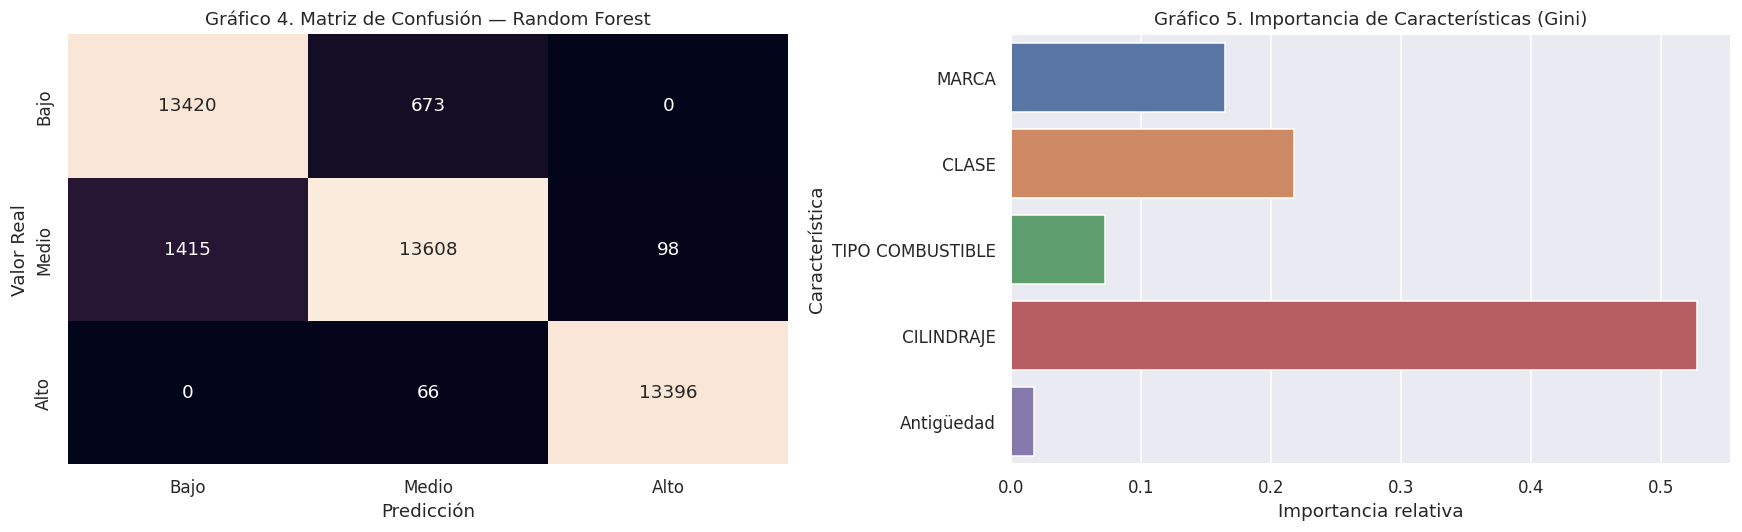

In [ ]:
plt.figure(figsize=(16, 5))


# ============================================================
# 1. MATRIZ DE CONFUSIÓN — RANDOM FOREST
# ============================================================

plt.subplot(1, 2, 1)

rf_model = modelos['Random Forest']

rf_pred = rf_model.predict(
    X_test
)

cm = confusion_matrix(
    y_test,
    rf_pred,
    labels=[
        'Bajo',
        'Medio',
        'Alto'
    ]
)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cbar=False,
    xticklabels=[
        'Bajo',
        'Medio',
        'Alto'
    ],
    yticklabels=[
        'Bajo',
        'Medio',
        'Alto'
    ]
)

plt.title(
    'Gráfico 4. Matriz de Confusión — Random Forest'
)

plt.xlabel('Predicción')
plt.ylabel('Valor Real')


# ============================================================
# 2. IMPORTANCIA DE VARIABLES
# ============================================================

plt.subplot(1, 2, 2)

importances = (
    rf_model.feature_importances_
)

features = [
    'MARCA',
    'CLASE',
    'TIPO COMBUSTIBLE',
    'CILINDRAJE',
    'Antigüedad'
]

sns.barplot(
    x=importances,
    y=features,
    hue=features,
    legend=False
)

plt.title(
    'Gráfico 5. Importancia de Características (Gini)'
)

plt.xlabel(
    'Importancia relativa'
)

plt.ylabel('Característica')

plt.tight_layout()
plt.show()

## 14. Persistencia del Modelo

Se guarda el modelo entrenado en disco con `joblib` para su posterior despliegue en una API o aplicación web.

In [ ]:
# ============================================================
# GUARDAR MODELO Y SCALER
# ============================================================

joblib.dump(
    rf_model,
    "modelo_vehiculos_sri.pkl"
)

joblib.dump(
    scaler,
    "scaler_vehiculos_sri.pkl"
)

print(
    "✅ Modelo y escalador guardados correctamente"
)

print(
    "   • modelo_vehiculos_sri.pkl"
)

print(
    "   • scaler_vehiculos_sri.pkl"
)

✅ Modelo y escalador guardados correctamente
   • modelo_vehiculos_sri.pkl
   • scaler_vehiculos_sri.pkl
